# Artifical Neural Network

### We use ANN in FNN, CNN, RNN



# Feedforward Neural Network

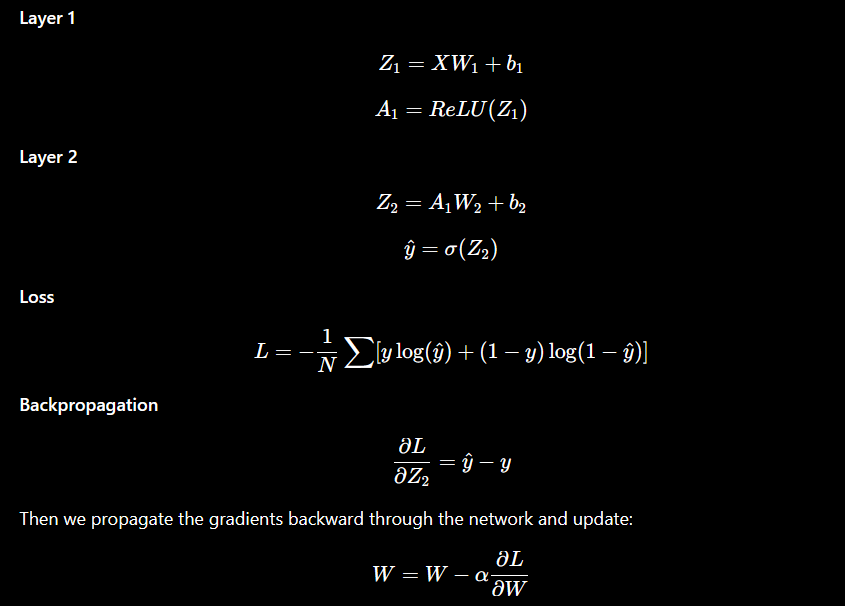

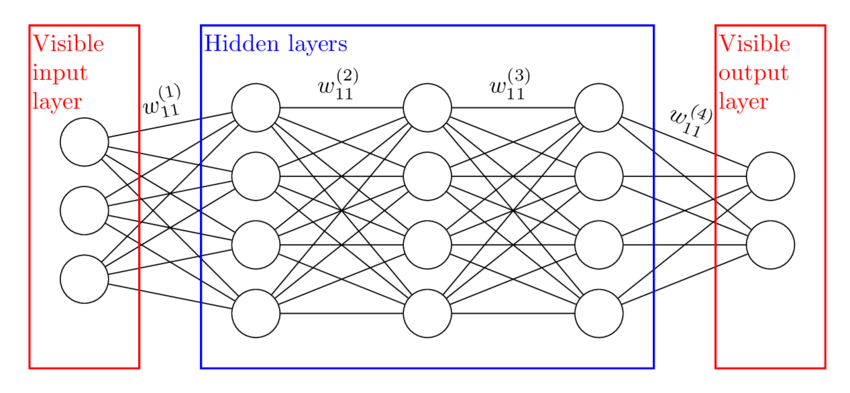

X shape: (200, 2)
y shape: (200, 1)

Network:
Input : 2
Hidden: 8
Output: 1
Epoch    0 | Loss: 1.9120 | Accuracy: 50.00%
Epoch  500 | Loss: 0.0378 | Accuracy: 99.50%
Epoch 1000 | Loss: 0.0215 | Accuracy: 99.50%
Epoch 1500 | Loss: 0.0158 | Accuracy: 99.50%
Epoch 2000 | Loss: 0.0127 | Accuracy: 99.50%
Epoch 2500 | Loss: 0.0107 | Accuracy: 99.50%
Epoch 3000 | Loss: 0.0092 | Accuracy: 99.50%
Epoch 3500 | Loss: 0.0081 | Accuracy: 99.50%
Epoch 4000 | Loss: 0.0072 | Accuracy: 100.00%
Epoch 4500 | Loss: 0.0064 | Accuracy: 100.00%

Final Accuracy: 100.0 %


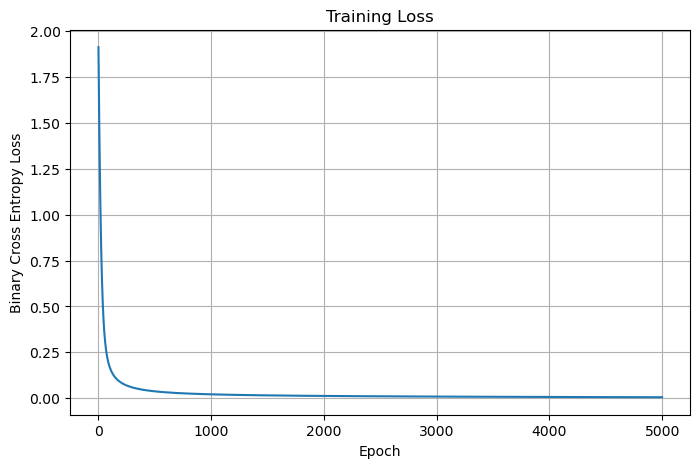

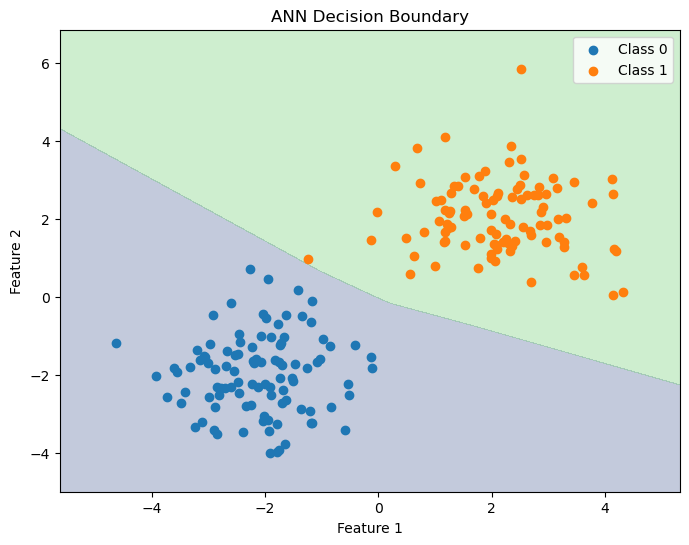

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. CREATE DATASET
# ============================================================

np.random.seed(42)

# Class 0
X0 = np.random.randn(100, 2) + np.array([-2, -2])

# Class 1
X1 = np.random.randn(100, 2) + np.array([2, 2])

X = np.vstack((X0, X1))

y = np.vstack((
    np.zeros((100, 1)),
    np.ones((100, 1))
))

print("X shape:", X.shape)
print("y shape:", y.shape)


# ============================================================
# 2. ACTIVATION FUNCTIONS
# ============================================================

def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(float)


def sigmoid(x):
    # Prevent overflow
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))


# ============================================================
# 3. LOSS FUNCTION
# ============================================================

def binary_cross_entropy(y_true, y_pred):

    # Avoid log(0)
    epsilon = 1e-8

    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.mean(
        y_true * np.log(y_pred)
        +
        (1 - y_true) * np.log(1 - y_pred)
    )

    return loss


# ============================================================
# 4. INITIALIZE NETWORK
# ============================================================

input_size = 2
hidden_size = 8
output_size = 1

learning_rate = 0.01
epochs = 5000


# Xavier-style initialization

W1 = np.random.randn(input_size, hidden_size) * np.sqrt(1 / input_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1 / hidden_size)
b2 = np.zeros((1, output_size))


print("\nNetwork:")
print("Input :", input_size)
print("Hidden:", hidden_size)
print("Output:", output_size)


# ============================================================
# 5. TRAINING
# ============================================================

loss_history = []


for epoch in range(epochs):

    # --------------------------------------------------------
    # FORWARD PROPAGATION
    # --------------------------------------------------------

    # Input -> Hidden
    Z1 = X @ W1 + b1

    A1 = relu(Z1)

    # Hidden -> Output
    Z2 = A1 @ W2 + b2

    A2 = sigmoid(Z2)


    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    loss = binary_cross_entropy(y, A2)

    loss_history.append(loss)


    # --------------------------------------------------------
    # BACKPROPAGATION
    # --------------------------------------------------------

    # Output layer
    #
    # For sigmoid + binary cross entropy:
    #
    # dZ2 = A2 - y

    dZ2 = A2 - y

    dW2 = (A1.T @ dZ2) / len(X)

    db2 = np.sum(dZ2, axis=0, keepdims=True) / len(X)


    # Hidden layer

    dA1 = dZ2 @ W2.T

    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = (X.T @ dZ1) / len(X)

    db1 = np.sum(dZ1, axis=0, keepdims=True) / len(X)


    # --------------------------------------------------------
    # GRADIENT DESCENT
    # --------------------------------------------------------

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1


    # --------------------------------------------------------
    # PRINT PROGRESS
    # --------------------------------------------------------

    if epoch % 500 == 0:

        predictions = (A2 >= 0.5).astype(int)

        accuracy = np.mean(predictions == y)

        print(
            f"Epoch {epoch:4d} | "
            f"Loss: {loss:.4f} | "
            f"Accuracy: {accuracy * 100:.2f}%"
        )


# ============================================================
# 6. FINAL PREDICTIONS
# ============================================================

Z1 = X @ W1 + b1
A1 = relu(Z1)

Z2 = A1 @ W2 + b2
A2 = sigmoid(Z2)

predictions = (A2 >= 0.5).astype(int)

accuracy = np.mean(predictions == y)

print("\nFinal Accuracy:", accuracy * 100, "%")


# ============================================================
# 7. PLOT LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Training Loss")

plt.grid()

plt.show()


# ============================================================
# 8. DECISION BOUNDARY
# ============================================================

x_min = X[:, 0].min() - 1
x_max = X[:, 0].max() + 1

y_min = X[:, 1].min() - 1
y_max = X[:, 1].max() + 1


xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)


grid = np.c_[xx.ravel(), yy.ravel()]


# Forward pass through trained network

Z1_grid = grid @ W1 + b1
A1_grid = relu(Z1_grid)

Z2_grid = A1_grid @ W2 + b2
A2_grid = sigmoid(Z2_grid)


Z = A2_grid.reshape(xx.shape)


plt.figure(figsize=(8, 6))

plt.contourf(
    xx,
    yy,
    Z,
    levels=[0, 0.5, 1],
    alpha=0.3
)

plt.scatter(
    X0[:, 0],
    X0[:, 1],
    label="Class 0"
)

plt.scatter(
    X1[:, 0],
    X1[:, 1],
    label="Class 1"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title("ANN Decision Boundary")

plt.legend()

plt.show()